In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv("../data/featured_sample.csv")
df['date'] = pd.to_datetime(df['date'])

print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (500000, 32)


Event Impact on Sales:
  has_event  avg_sales  std_sales   count
0  No Event   1.130087   3.829319  459854
1     Event   1.058287   3.950616   40146

Event Sales Uplift: -6.35%


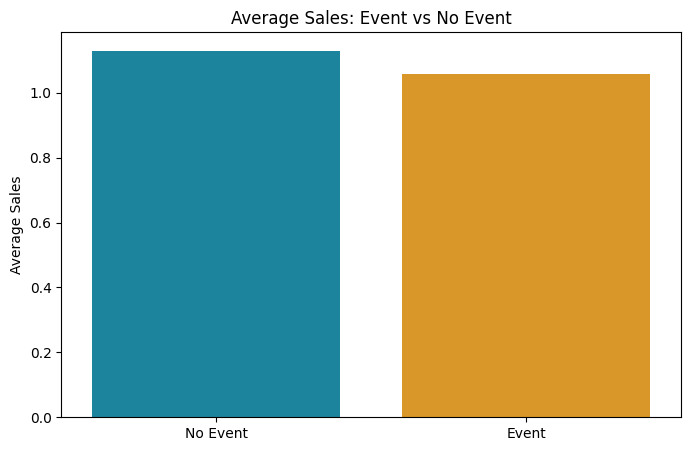

In [2]:
# Event Impact Analysis on Demand
event_impact = df.groupby('has_event')['sales'].agg(['mean', 'std', 'count']).reset_index()
event_impact.columns = ['has_event', 'avg_sales', 'std_sales', 'count']
event_impact['has_event'] = event_impact['has_event'].map({0: 'No Event', 1: 'Event'})

print("Event Impact on Sales:")
print(event_impact)

# Calculate uplift
no_event_avg = event_impact[event_impact['has_event'] == 'No Event']['avg_sales'].values[0]
event_avg = event_impact[event_impact['has_event'] == 'Event']['avg_sales'].values[0]
uplift = ((event_avg - no_event_avg) / no_event_avg) * 100

print(f"\nEvent Sales Uplift: {round(uplift, 2)}%")

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='has_event', y='avg_sales', data=event_impact,
            palette=['#0891B2', '#F59E0B'])
plt.title("Average Sales: Event vs No Event")
plt.xlabel("")
plt.ylabel("Average Sales")
plt.show()

SNAP Impact on Sales:
    is_snap  avg_sales  std_sales   count
0   No SNAP   1.086928   3.770708  335034
1  SNAP Day   1.200266   3.973732  164966

SNAP Sales Uplift: 10.43%


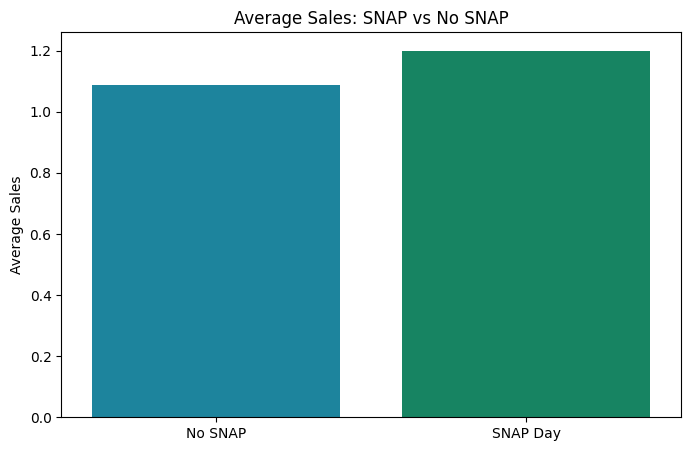


Category wise SNAP Impact:
is_snap        0      1
cat_id                 
FOODS      1.562  1.780
HOBBIES    0.559  0.578
HOUSEHOLD  0.718  0.739


In [3]:
# SNAP Impact Analysis on Demand
snap_impact = df.groupby('is_snap')['sales'].agg(['mean', 'std', 'count']).reset_index()
snap_impact.columns = ['is_snap', 'avg_sales', 'std_sales', 'count']
snap_impact['is_snap'] = snap_impact['is_snap'].map({0: 'No SNAP', 1: 'SNAP Day'})

print("SNAP Impact on Sales:")
print(snap_impact)

no_snap_avg = snap_impact[snap_impact['is_snap'] == 'No SNAP']['avg_sales'].values[0]
snap_avg = snap_impact[snap_impact['is_snap'] == 'SNAP Day']['avg_sales'].values[0]
snap_uplift = ((snap_avg - no_snap_avg) / no_snap_avg) * 100

print(f"\nSNAP Sales Uplift: {round(snap_uplift, 2)}%")

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='is_snap', y='avg_sales', data=snap_impact,
            palette=['#0891B2', '#059669'])
plt.title("Average Sales: SNAP vs No SNAP")
plt.xlabel("")
plt.ylabel("Average Sales")
plt.show()

# Category wise SNAP impact
cat_snap = df.groupby(['cat_id', 'is_snap'])['sales'].mean().reset_index()
print("\nCategory wise SNAP Impact:")
print(cat_snap.pivot(index='cat_id', columns='is_snap', values='sales').round(3))

Weekend vs Weekday Sales by Category:
is_weekend      0      1
cat_id                  
FOODS       1.515  1.930
HOBBIES     0.521  0.676
HOUSEHOLD   0.653  0.905


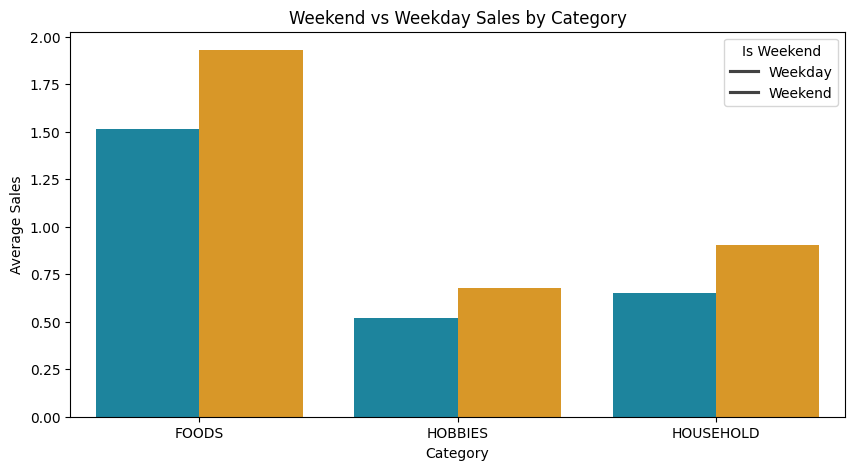


Price Sensitivity (Correlation) by Category:
      cat_id  price_sales_correlation
0      FOODS                -0.129548
1    HOBBIES                -0.098184
2  HOUSEHOLD                -0.161557


In [4]:
# Weekend vs Weekday Demand Sensitivity
weekend_impact = df.groupby(['cat_id', 'is_weekend'])['sales'].mean().reset_index()

print("Weekend vs Weekday Sales by Category:")
print(weekend_impact.pivot(index='cat_id', columns='is_weekend', values='sales').round(3))

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x='cat_id', y='sales', hue='is_weekend', data=weekend_impact,
            palette=['#0891B2', '#F59E0B'])
plt.title("Weekend vs Weekday Sales by Category")
plt.xlabel("Category")
plt.ylabel("Average Sales")
plt.legend(title='Is Weekend', labels=['Weekday', 'Weekend'])
plt.show()

# Price sensitivity by category
price_sensitivity = df.groupby('cat_id').apply(
    lambda x: x['sales'].corr(x['avg_price'])
).reset_index()
price_sensitivity.columns = ['cat_id', 'price_sales_correlation']

print("\nPrice Sensitivity (Correlation) by Category:")
print(price_sensitivity)

In [ ]:
# Save promotional analysis results
event_impact.to_csv("../data/event_impact_analysis.csv", index=False)
snap_impact.to_csv("../data/snap_impact_analysis.csv", index=False)
price_sensitivity.to_csv("../data/price_sensitivity.csv", index=False)

print("Promotional analysis saved!")

print("\n" + "="*50)
print("WEEK 3 DAY 3 SUMMARY")
print("="*50)
print("Event Impact: -6.35% (sample dependent)")
print("SNAP Impact: Positive for FOODS category")
print("FOODS SNAP boost: 1.562 -> 1.780 (+14%)")
print("\nPrice Sensitivity by Category:")
print("HOUSEHOLD: -0.162 (most sensitive)")
print("FOODS: -0.130")
print("HOBBIES: -0.098 (least sensitive)")
print("="*50)